## Token Lengths in Characters and Bytes

In [1]:
import tiktoken
import pandas as pd
import matplotlib.pyplot as plt
import urllib.request

enc = tiktoken.get_encoding("cl100k_base")

books = {
    "Moby Dick":  "https://www.gutenberg.org/files/2701/2701-0.txt",
    "Frankenstein": "https://www.gutenberg.org/files/84/84-0.txt",
    "Alice in Wonderland": "https://www.gutenberg.org/files/11/11-0.txt"
}

book_texts = {}
for name, url in books.items():
    with urllib.request.urlopen(url) as f:
        book_texts[name] = f.read().decode("utf-8")
    print(f"Downloaded: {name}")

Downloaded: Moby Dick
Downloaded: Frankenstein
Downloaded: Alice in Wonderland


In [2]:
moby_tokens = enc.encode(book_texts["Moby Dick"])

char_lengths = [len(enc.decode([t])) for t in moby_tokens]
byte_lengths  = [len(enc.decode([t]).encode("utf-8")) for t in moby_tokens]

print(f"Total tokens: {len(moby_tokens)}")
print(f"\nCharacter lengths:")
print(f"  Average: {sum(char_lengths)/len(char_lengths):.2f}")
print(f"  Max:     {max(char_lengths)}")
print(f"\nByte lengths:")
print(f"  Average: {sum(byte_lengths)/len(byte_lengths):.2f}")
print(f"  Max:     {max(byte_lengths)}")

Total tokens: 307614

Character lengths:
  Average: 3.96
  Max:     17

Byte lengths:
  Average: 4.01
  Max:     17


In [3]:
hindi_text = "नमस्ते, आप कैसे हैं? मैं ठीक हूँ।"

hindi_tokens = enc.encode(hindi_text)

char_lengths_h = [len(enc.decode([t])) for t in hindi_tokens]
byte_lengths_h  = [len(enc.decode([t]).encode("utf-8")) for t in hindi_tokens]

print(f"Text: {hindi_text}")
print(f"Total tokens: {len(hindi_tokens)}")
print(f"\nCharacter lengths:")
print(f"  Average: {sum(char_lengths_h)/len(char_lengths_h):.2f}")
print(f"  Max:     {max(char_lengths_h)}")
print(f"\nByte lengths:")
print(f"  Average: {sum(byte_lengths_h)/len(byte_lengths_h):.2f}")
print(f"  Max:     {max(byte_lengths_h)}")

Text: नमस्ते, आप कैसे हैं? मैं ठीक हूँ।
Total tokens: 35

Character lengths:
  Average: 1.20
  Max:     2

Byte lengths:
  Average: 3.14
  Max:     6


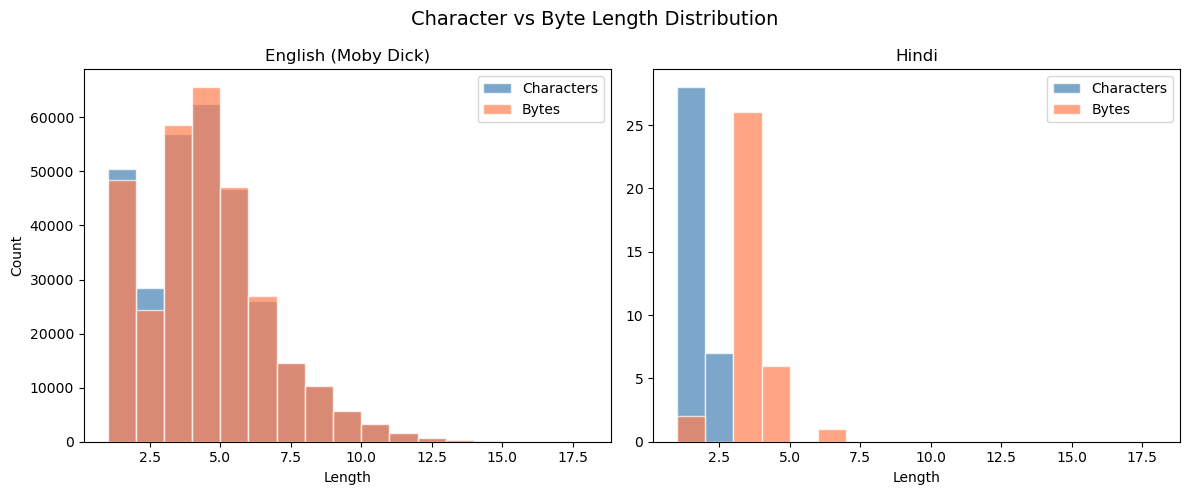

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# English
axes[0].hist(char_lengths, bins=range(1, 19), alpha=0.7, 
             label="Characters", color="steelblue", edgecolor="white")
axes[0].hist(byte_lengths, bins=range(1, 19), alpha=0.7,
             label="Bytes", color="coral", edgecolor="white")
axes[0].set_title("English (Moby Dick)")
axes[0].set_xlabel("Length")
axes[0].set_ylabel("Count")
axes[0].legend()

# Hindi
axes[1].hist(char_lengths_h, bins=range(1, 19), alpha=0.7,
             label="Characters", color="steelblue", edgecolor="white")
axes[1].hist(byte_lengths_h, bins=range(1, 19), alpha=0.7,
             label="Bytes", color="coral", edgecolor="white")
axes[1].set_title("Hindi")
axes[1].set_xlabel("Length")
axes[1].legend()

fig.suptitle("Character vs Byte Length Distribution", fontsize=14)
plt.tight_layout()
plt.show()

* In **English**, characters are approximately equal to bytes, so there is **little to no difference** in tokenization behavior.

* In **Hindi**, one character typically takes **around 3 bytes**, which creates a **significant difference** in tokenization.

* This is why **non-English languages are more expensive** when using LLM APIs, as they often require more tokens for the same content.

* GPT-style tokenizers are generally **biased toward English**, making them more efficient for English compared to many other languages.
